In [75]:
# Cell 1: Imports and environment setup
import os
import re
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Initialise device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# File paths (ensure your 'data' directory is set up correctly)
DATA_DIR = os.path.join(os.getcwd(), 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Test.csv')

Device: cuda


In [76]:
# Cell 2: Load the training data
df = pd.read_csv(TRAIN_CSV)
df = df.dropna(subset=['message', 'label']).reset_index(drop=True)

print(f'Loaded {len(df)} rows')

Loaded 2119 rows


C:\Users\fynle\AppData\Local\Temp\ipykernel_17952\1882331065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


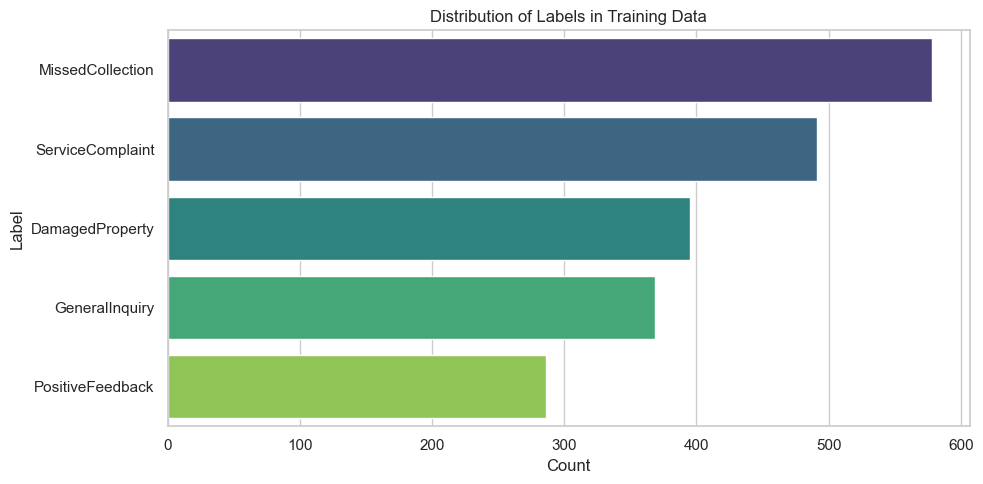

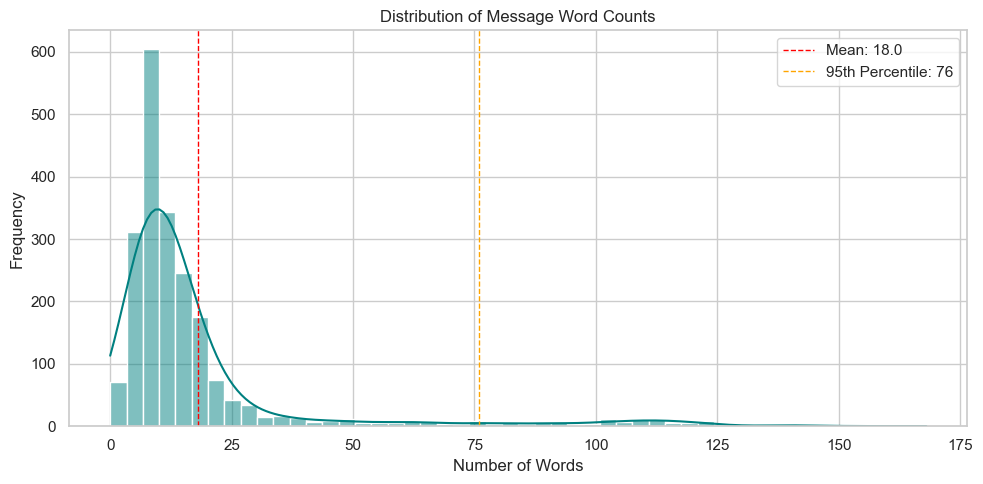

Basic statistics of word counts:
count    2119.000000
mean       17.998584
std        23.073465
min         0.000000
25%         7.000000
50%        11.000000
75%        17.000000
max       168.000000
Name: word_count, dtype: float64


In [77]:
# Cell 3: Exploratory Data Analysis (EDA)
# Set the visual style for our plots
sns.set_theme(style="whitegrid")

# 1. Analyse the class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Labels in Training Data')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

# Quick text cleaning function to standardise our text before length analysis
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['text'] = df['message'].apply(clean_text)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 2. Visualise sequence lengths to help us choose a sensible MAX_LEN
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Message Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean: {df['word_count'].mean():.1f}")
plt.axvline(df['word_count'].quantile(0.95), color='orange', linestyle='dashed', linewidth=1, label=f"95th Percentile: {df['word_count'].quantile(0.95):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print("Basic statistics of word counts:")
print(df['word_count'].describe())

In [78]:
# Cell 4: Pre-processing and tokenisation
# Map labels to indices
labels = sorted(df['label'].unique())
label2idx = {l: i for i, l in enumerate(labels)}
idx2label = {i: l for l, i in label2idx.items()}
print('Labels mapping:', label2idx)

# Train/validation split (stratified to maintain class balance)
train_df, val_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['label'])
print(f'Train size: {len(train_df)} | Validation size: {len(val_df)}')

# Build vocabulary from training data only to avoid data leakage
counter = Counter()
for t in train_df['text']:
    counter.update(t.split())

# Keep words with frequency >= 2 to filter out rare typos
min_freq = 2
vocab = {w for w, f in counter.items() if f >= min_freq}

# Special tokens for padding and unknown words
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

itos = [PAD_TOKEN, UNK_TOKEN] + sorted(vocab)
stoi = {s: i for i, s in enumerate(itos)}
vocab_size = len(itos)
print(f'Final vocabulary size: {vocab_size}')

# Based on our EDA (95th percentile), we can set a sensible MAX_LEN
MAX_LEN = int(df['word_count'].quantile(0.95))
# Cap it at a minimum of 50 just in case the messages are very short
MAX_LEN = max(50, MAX_LEN) 
print(f'Using MAX_LEN: {MAX_LEN}')

def encode(text, max_len=MAX_LEN):
    toks = text.split()
    ids = [stoi.get(t, stoi[UNK_TOKEN]) for t in toks][:max_len]
    # Pad sequences that are shorter than max_len
    if len(ids) < max_len:
        ids = ids + [stoi[PAD_TOKEN]] * (max_len - len(ids))
    return ids

# Apply encoding
train_df['input_ids'] = train_df['text'].apply(lambda t: encode(t, MAX_LEN))
val_df['input_ids'] = val_df['text'].apply(lambda t: encode(t, MAX_LEN))

Labels mapping: {'DamagedProperty': 0, 'GeneralInquiry': 1, 'MissedCollection': 2, 'PositiveFeedback': 3, 'ServiceComplaint': 4}
Train size: 1801 | Validation size: 318
Final vocabulary size: 1748
Using MAX_LEN: 76


In [79]:
# Cell 5: Create PyTorch Datasets and DataLoaders
class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.inputs = dataframe['input_ids'].tolist()
        self.labels = [label2idx[l] for l in dataframe['label'].tolist()]
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = TextDataset(train_df)
val_ds = TextDataset(val_df)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print('DataLoaders successfully initialised.')

DataLoaders successfully initialised.


In [80]:
# Cell 6: Define the Positional Encoding and Transformer Model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        # Create a matrix of shape (max_len, d_model) to hold the positional encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Use sine and cosine functions of different frequencies
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0) # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding to the embeddings
        x = x + self.pe[:, :x.size(1), :]
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2, num_classes=5, dropout=0.5, padding_idx=0, max_len=100):
        super().__init__()
        self.padding_idx = padding_idx
        
        # 1. Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        
        # 2. Positional encoding
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_len)
        
        # 3. Transformer Encoder layers
        # batch_first=True means inputs are shape (batch, seq, feature)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=hidden_dim, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 4. Classification head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Create a boolean mask to ignore padding tokens in attention
        # True values represent positions to be ignored
        pad_mask = (x == self.padding_idx)
        
        # Embed and add positional encoding
        emb = self.embedding(x)                 # (batch, seq_len, embed_dim)
        emb = self.pos_encoder(emb)             # (batch, seq_len, embed_dim)
        
        # Pass through transformer
        # src_key_padding_mask stops attention mechanism from looking at <pad> tokens
        transformer_out = self.transformer_encoder(emb, src_key_padding_mask=pad_mask)
        
        # Pooling strategy: Take the mean of non-padded tokens for the final representation
        # Create a mask of 1s and 0s
        active_tokens = (~pad_mask).unsqueeze(-1).float() 
        sum_embeddings = torch.sum(transformer_out * active_tokens, dim=1)
        valid_lengths = torch.clamp(active_tokens.sum(dim=1), min=1e-9)
        pooled_out = sum_embeddings / valid_lengths
        
        # Final classification
        out = self.dropout(pooled_out)
        logits = self.fc(out)
        return logits

# Initialise the model
DROPOUT = 0.5
# Updated Initialisation in Cell 6
model = TransformerClassifier(
    vocab_size=vocab_size, 
    embed_dim=256,
    num_heads=8,
    hidden_dim=512,
    num_layers=2,
    num_classes=len(labels), 
    dropout=0.2,
    padding_idx=stoi[PAD_TOKEN],
    max_len=MAX_LEN
).to(device)

print(model)

TransformerClassifier(
  (embedding): Embedding(1748, 256, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)


In [81]:
# Cell 7: Define Early Stopping and Training/Evaluation Loops
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, score, model):
        # Higher score (accuracy) is better
        if self.best_score is None or (score - self.best_score) > self.min_delta:
            self.best_score = score
            self.num_bad_epochs = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False 
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                return True
            return False

    def load_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        
        # Clip gradients to prevent exploding gradients (common in transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
        
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
            
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(yb.cpu().numpy().tolist())
            
    return total_loss / total, correct / total, all_preds, all_labels

In [82]:
# Cell 8: Run the Training Loop

# 1. Label smoothing prevents the model from becoming overconfident
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Add weight_decay to the optimizer for L2 regularisation
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# 3. Add a Learning Rate Scheduler (Removed the deprecated 'verbose=True')
# This will reduce the learning rate by half (factor=0.5) if val_loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

best_val = 0.0
early_stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

os.makedirs(DATA_DIR, exist_ok=True)
ckpt_path = os.path.join(DATA_DIR, 'transformer_checkpoint.pth')

# Keep track of the learning rate so we can print when it changes
current_lr = optimizer.param_groups[0]['lr']

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Manually check if the learning rate dropped and print it
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f"\n📉 Learning rate dropped from {current_lr:.2e} to {new_lr:.2e}\n")
        current_lr = new_lr
    
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    
    # Save checkpoint on improvement
    if val_acc > best_val + MIN_DELTA:
        best_val = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'stoi': stoi,
            'itos': itos,
            'label2idx': label2idx,
            'idx2label': idx2label,
            'max_len': MAX_LEN
        }, ckpt_path)
        print(' -> Saved best model')
        
    if early_stopper.step(val_acc, model):
        print(f"Early stopping triggered (no validation accuracy improvement for {PATIENCE} epochs).")
        break

early_stopper.load_best(model)

Epoch 01: train_loss=1.2023, train_acc=0.5813 | val_loss=0.8680, val_acc=0.7830
 -> Saved best model
Epoch 02: train_loss=0.7321, train_acc=0.8479 | val_loss=0.8426, val_acc=0.7579
Epoch 03: train_loss=0.6108, train_acc=0.9106 | val_loss=0.7356, val_acc=0.8553
 -> Saved best model
Epoch 04: train_loss=0.5282, train_acc=0.9522 | val_loss=0.6915, val_acc=0.8742
 -> Saved best model
Epoch 05: train_loss=0.4813, train_acc=0.9689 | val_loss=0.6994, val_acc=0.8616
Epoch 06: train_loss=0.4435, train_acc=0.9906 | val_loss=0.7172, val_acc=0.8553
Epoch 07: train_loss=0.4208, train_acc=0.9922 | val_loss=0.6849, val_acc=0.8679
Epoch 08: train_loss=0.4141, train_acc=0.9944 | val_loss=0.6713, val_acc=0.8742
Epoch 09: train_loss=0.4145, train_acc=0.9939 | val_loss=0.7228, val_acc=0.8679
Epoch 10: train_loss=0.4049, train_acc=0.9978 | val_loss=0.7108, val_acc=0.8836
 -> Saved best model
Epoch 11: train_loss=0.4003, train_acc=0.9972 | val_loss=0.7147, val_acc=0.8742
Epoch 12: train_loss=0.4000, train_a

Final Validation Accuracy: 0.8836

Classification Report:
                  precision    recall  f1-score   support

 DamagedProperty       0.85      0.97      0.90        59
  GeneralInquiry       1.00      0.91      0.95        55
MissedCollection       0.87      0.92      0.89        87
PositiveFeedback       0.88      0.81      0.84        43
ServiceComplaint       0.86      0.80      0.83        74

        accuracy                           0.88       318
       macro avg       0.89      0.88      0.88       318
    weighted avg       0.89      0.88      0.88       318



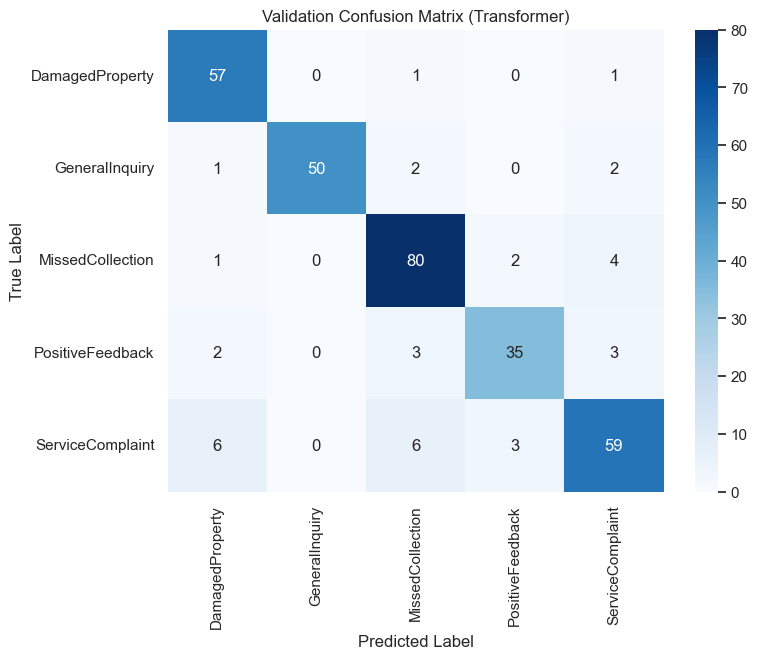

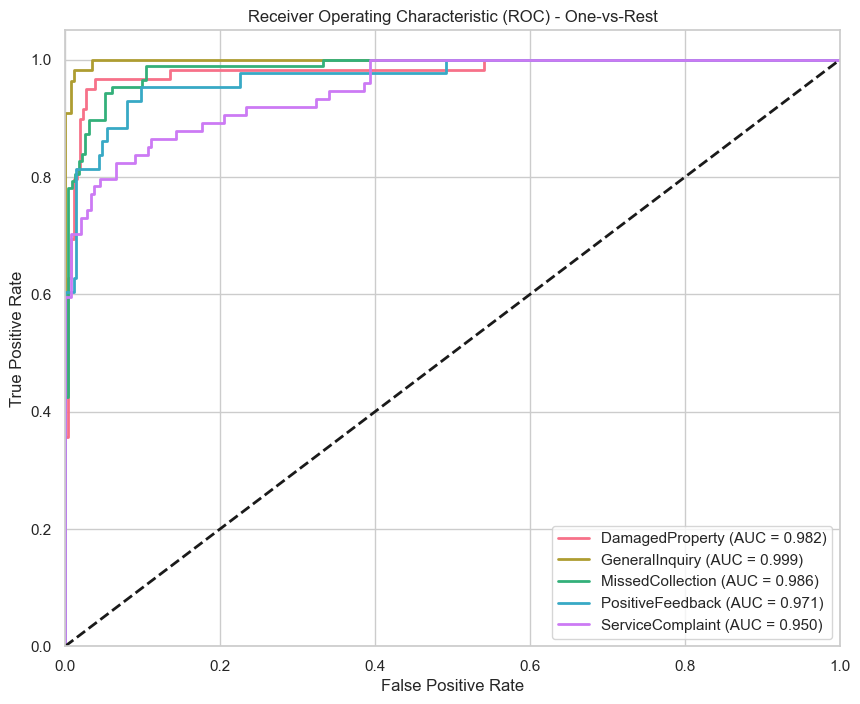


ROC AUC Scores Table:


,Class,ROC AUC Score
0,GeneralInquiry,0.998756
1,MissedCollection,0.985520
2,DamagedProperty,0.981938
3,PositiveFeedback,0.970994
4,ServiceComplaint,0.949878


In [86]:
# Cell 9: Final Evaluation, Confusion Matrix, and ROC Analysis
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Standard Evaluation
val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

print(f'Final Validation Accuracy: {val_acc:.4f}')
print('\nClassification Report:')
print(classification_report(val_labels, val_preds, target_names=labels))

# 2. Visualise the Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix (Transformer)')
plt.show()

# 3. Gather probabilities for ROC Analysis
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(yb.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Binarise the labels for One-vs-Rest ROC calculation
n_classes = len(labels)
y_test_bin = label_binarize(all_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 8))
colors = sns.color_palette("husl", n_classes)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{labels[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest')
plt.legend(loc="lower right")
plt.show()

# 5. Display the ROC AUC Table
roc_table = pd.DataFrame({
    'Class': labels,
    'ROC AUC Score': [roc_auc[i] for i in range(n_classes)]
})

# Sort the table from highest performing to lowest performing
roc_table = roc_table.sort_values(by='ROC AUC Score', ascending=False).reset_index(drop=True)

print("\nROC AUC Scores Table:")
display(roc_table) # Use print(roc_table) if you are not in a Jupyter environment

In [87]:
# Cell 10: Inference helpers and demonstrations
# Reload model from disk to verify our save/load behaviour
ckpt = torch.load(ckpt_path, map_location=device)

# Re-initialise model with the UPDATED saved dimensions
inference_model = TransformerClassifier(
    vocab_size=len(ckpt['itos']), 
    embed_dim=256,         # Updated from 128 to match our new architecture
    num_heads=8,           # Updated from 4
    hidden_dim=512,        # Updated from 256
    num_layers=2, 
    num_classes=len(ckpt['idx2label']),
    padding_idx=ckpt['stoi'][PAD_TOKEN],
    max_len=ckpt.get('max_len', 100)
).to(device)

inference_model.load_state_dict(ckpt['model_state'])
inference_model.eval()

inf_stoi = ckpt['stoi']
inf_idx2label = ckpt['idx2label']
INF_MAX_LEN = ckpt.get('max_len', 100)
INF_PAD_TOKEN = '<pad>'
INF_UNK_TOKEN = '<unk>'

def preprocess_and_encode_inf(text):
    t = clean_text(text)
    toks = t.split()
    ids = [inf_stoi.get(w, inf_stoi[INF_UNK_TOKEN]) for w in toks][:INF_MAX_LEN]
    if len(ids) < INF_MAX_LEN:
        ids = ids + [inf_stoi[INF_PAD_TOKEN]] * (INF_MAX_LEN - len(ids))
    return torch.tensor([ids], dtype=torch.long)

def predict(text):
    xb = preprocess_and_encode_inf(text).to(device)
    with torch.no_grad():
        logits = inference_model(xb)
        p = torch.softmax(logits, dim=1)[0]
        pred = p.argmax().item()
        return inf_idx2label[pred], p[pred].item()

# Test the inference pipeline
examples = [
    "My bin wasn't emptied today and it's overflowing",
    "Your driver broke my gate during collection",
    "Love the service — drivers are always friendly!",
    "Do you collect batteries?",
    "The crew left my bin on the pavement blocking the path"
]

print("Predictions:")
for ex in examples:
    label, score = predict(ex)
    print(f"[{score:.2f}] {label.upper()} <- '{ex}'")

Predictions:
[0.95] MISSEDCOLLECTION <- 'My bin wasn't emptied today and it's overflowing'
[0.96] DAMAGEDPROPERTY <- 'Your driver broke my gate during collection'
[0.96] POSITIVEFEEDBACK <- 'Love the service — drivers are always friendly!'
[0.94] GENERALINQUIRY <- 'Do you collect batteries?'
[0.72] SERVICECOMPLAINT <- 'The crew left my bin on the pavement blocking the path'
